# Fard Masoumi et al. (2011): a Taguchi L9 esterification study

## 0. Reproducibility card

| Item | Record |
|---|---|
| Article | Fard Masoumi, H. R.; Kassim, A.; Basri, M.; Abdullah, D. K. (2011). *Determining Optimum Conditions for Lipase-Catalyzed Synthesis of Triethanolamine (TEA)-Based Esterquat Cationic Surfactant by a Taguchi Robust Design Method*. **Molecules, 16**, 4672–4680. |
| DOI | [10.3390/molecules16064672](https://doi.org/10.3390/molecules16064672) |
| Open-access route | [PubMed Central, PMCID PMC6264298](https://pmc.ncbi.nlm.nih.gov/articles/PMC6264298/) |
| Licence | [CC BY 3.0](https://creativecommons.org/licenses/by/3.0/) |
| Citation snapshot | 42 Crossref citations, retrieved 2026-08-01 through the [Crossref public API](https://api.crossref.org/works/10.3390%2Fmolecules16064672). Counts vary by database. |
| Reproduction level | **Level B — analytical reproduction.** The numerical fit is reproducible, but Table 4 misassigns three coefficients to factor labels and the desirability settings are incomplete. |
| Core tools | `pydoe`, NumPy, pandas, SciPy, statsmodels, scikit-learn, matplotlib |
| Random seed | 20110603 |
| Reproduced | L9 orthogonal-array geometry; physical coding; fitted values; modified linear model; ANOVA; RMSE, PRESS, $R^2$, adequate precision; confirmation predictions. |
| Not exactly reproducible | Design-Expert desirability weights; run randomization; pure error; independent Taguchi noise response; raw confirmation replicates beyond the three reported outcomes. |

**Evidence labels used below:** “paper” means reported by the article; “reproduction” means calculated from its printed Tables 1 and 6; “teaching analysis” means a new notebook result. No new laboratory observations are implied.

> **Practitioner reading guide.** Every case follows the same path: scientific context → evidence and provenance → design reconstruction → design diagnostics → article analysis → publication checks → a clearly labelled teaching extension → practitioner conclusions → reproducibility metadata. **Paper** denotes a published result, **reproduction** a notebook calculation from available evidence, and **teaching analysis** a new demonstration rather than new experimental evidence. Install the shared [`requirements.txt`](requirements.txt); Section 9 records the detailed environment used for this notebook's saved execution.


In [1]:
from __future__ import annotations

import hashlib
import os
import platform
import tempfile
import warnings
from itertools import combinations
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "mpl-fardmasoumi2011"))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydoe
import scipy
from scipy import optimize, stats
import sklearn
import statsmodels
import statsmodels.api as sm
from pydoe import taguchi_design

SEED = 20110603
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
warnings.filterwarnings("ignore", category=RuntimeWarning)

mpl.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (9, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 9,
})

versions = {
    "Python": platform.python_version(),
    "pydoe": getattr(pydoe, "__version__", "development checkout"),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "statsmodels": statsmodels.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": mpl.__version__,
}
pd.Series(versions, name="version").to_frame()

,version
Python,3.13.2
pydoe,1.3.1.dev11+geca1a2598
numpy,2.3.4
pandas,3.0.0
scipy,1.16.2
statsmodels,0.14.6
scikit-learn,1.9.0
matplotlib,3.11.1


## 1. Scientific context

The experimental unit is a 50 mL flask containing oleic acid (OA), triethanolamine (TEA), hexane, and immobilized *Candida antarctica* lipase B (Novozym 435). Reactions ran under reflux with magnetic stirring. Conversion of free acid to ester was determined by titration after the enzyme was filtered out.

| Coded factor | Physical factor | Type | −1 | 0 | +1 |
|---|---|---|---:|---:|---:|
| $X_1$ | enzyme amount (% w/w of oleic acid) | quantitative | 3 | 5 | 7 |
| $X_2$ | reaction time (h) | quantitative | 8 | 16 | 24 |
| $X_3$ | reaction temperature (°C) | quantitative | 55 | 60 | 65 |
| $X_4$ | OA:TEA molar ratio | quantitative ratio | 1:1 | 2:1 | 3:1 |

The response is reaction conversion (%). The paper uses a nine-run, four-factor, three-level L9 orthogonal array. Each factor level occurs three times and every pair of factors contains every level pair once. This supports clean **main-effect contrasts** at a small run budget.

No blocks, response replicates, explicit noise-factor array, or randomization procedure are reported. Consequently, the experiment can estimate systematic trends under the nine observed conditions, but it cannot separately estimate pure error, test lack of fit, or demonstrate robustness to a deliberately varied noise factor.

## 2. Data provenance and reproduction boundary

The coded run matrix, observed conversion, and printed fitted values are manually transcribed at published precision from **Table 1**. Physical levels come from **Table 6**. Tables 2–5 provide model-selection, ANOVA, coefficient, and confirmation targets. The data are redistributed here under the article's CC BY 3.0 licence.

Assertions check run numbering, factor levels, balance, missingness, response bounds, and printed predictions. Raw columns remain untouched; physical and analytical columns are derived separately. A checksum makes future changes visible.

In [2]:
raw = pd.DataFrame(
    [
        (1,  0, -1,  0,  0, 48.34, 47.29),
        (2,  1,  0,  0, -1, 46.27, 45.37),
        (3, -1,  1,  0,  1, 45.18, 44.28),
        (4,  1,  1, -1,  0, 42.32, 43.01),
        (5, -1, -1, -1, -1, 38.98, 39.51),
        (6,  1, -1,  1,  1, 54.54, 55.07),
        (7, -1,  0,  1,  0, 45.95, 46.64),
        (8,  0,  0, -1,  1, 49.29, 49.50),
        (9,  0,  1,  1, -1, 39.94, 40.15),
    ],
    columns=["run", "x1", "x2", "x3", "x4", "conversion_pct", "paper_fitted_pct"],
)

assert raw["run"].tolist() == list(range(1, 10))
assert set(raw[["x1", "x2", "x3", "x4"]].to_numpy().ravel()) == {-1, 0, 1}
assert all(raw[f"x{i}"].value_counts().sort_index().tolist() == [3, 3, 3] for i in range(1, 5))
assert raw.isna().sum().sum() == 0
assert raw["conversion_pct"].between(0, 100).all()

data = raw.assign(
    enzyme_pct=lambda d: 5 + 2*d["x1"],
    time_h=lambda d: 16 + 8*d["x2"],
    temperature_C=lambda d: 60 + 5*d["x3"],
    oa_to_tea_ratio=lambda d: 2 + d["x4"],
)
csv_bytes = raw.to_csv(index=False, lineterminator="\n").encode()
DATA_SHA256 = hashlib.sha256(csv_bytes).hexdigest()
print("Tables 1/6 transcription SHA-256:", DATA_SHA256)
data

Tables 1/6 transcription SHA-256: 88170e526c227266d3e815858b3ed88144c7b303a791b474abe7bdc1ae2394d1


,run,x1,x2,x3,x4,conversion_pct,paper_fitted_pct,enzyme_pct,time_h,temperature_C,oa_to_tea_ratio
0,1,0,-1,0,0,48.34,47.29,5,8,60,2
1,2,1,0,0,-1,46.27,45.37,7,16,60,1
2,3,-1,1,0,1,45.18,44.28,3,24,60,3
3,4,1,1,-1,0,42.32,43.01,7,24,55,2
4,5,-1,-1,-1,-1,38.98,39.51,3,8,55,1
5,6,1,-1,1,1,54.54,55.07,7,8,65,3
6,7,-1,0,1,0,45.95,46.64,3,16,65,2
7,8,0,0,-1,1,49.29,49.50,5,16,55,3
8,9,0,1,1,-1,39.94,40.15,5,24,65,1


## 3. Reconstruct the design

`pydoe.taguchi_design("L9(3^4)", ...)` generates a canonical L9. Orthogonal arrays are not unique: rows may be permuted, columns may be permuted, and factor levels may be relabelled without changing their statistical structure. The paper's array is obtained from the canonical `pydoe` array by relabelling levels 0 and +1 in columns 2 and 4, followed by a row permutation.

Matching is therefore done on the transformed coded settings, not by assuming that canonical row order equals laboratory run order.

In [3]:
canonical = taguchi_design("L9(3^4)", [[-1, 0, 1]] * 4).astype(int)
level_maps = [
    {-1: -1, 0: 0, 1: 1},
    {-1: -1, 0: 1, 1: 0},
    {-1: -1, 0: 0, 1: 1},
    {-1: -1, 0: 1, 1: 0},
]
transformed = np.column_stack([
    [level_maps[j][int(value)] for value in canonical[:, j]] for j in range(4)
])
generated = pd.DataFrame(transformed, columns=["x1", "x2", "x3", "x4"])
generated.insert(0, "pydoe_order", np.arange(1, 10))

matched = raw.merge(generated, on=["x1", "x2", "x3", "x4"], validate="one_to_one")
assert len(matched) == 9
assert set(map(tuple, raw[["x1", "x2", "x3", "x4"]].to_numpy())) == set(map(tuple, transformed))
matched.sort_values("run")[["run", "pydoe_order", "x1", "x2", "x3", "x4", "conversion_pct"]]

,run,pydoe_order,x1,x2,x3,x4,conversion_pct
0,1,4,0,-1,0,0,48.34
1,2,9,1,0,0,-1,46.27
2,3,2,-1,1,0,1,45.18
3,4,8,1,1,-1,0,42.32
4,5,1,-1,-1,-1,-1,38.98
5,6,7,1,-1,1,1,54.54
6,7,3,-1,0,1,0,45.95
7,8,6,0,0,-1,1,49.29
8,9,5,0,1,1,-1,39.94


## 4. Understand the design

**Balance** means each factor level is observed equally often. **Strength 2** means every two-factor projection is a complete 3×3 grid: no factor's main-effect contrast is preferentially paired with another factor's level. Using linear and quadratic polynomial contrasts, a full categorical main-effect model has $1+4(3-1)=9$ coefficients—exactly the run count. It is estimable but saturated, leaving zero residual degrees of freedom.

The paper instead fits six coefficients: intercept, four linear trends, and time curvature. That restriction leaves three residual degrees of freedom, but those residuals are model-dependent; without replicated settings they are not pure experimental error.

In [4]:
coded = data[["x1", "x2", "x3", "x4"]].to_numpy(dtype=float)

balance = pd.DataFrame({f"X{i}": data[f"x{i}"].value_counts().sort_index() for i in range(1, 5)})
display(balance.rename_axis("coded level"))

pair_checks = []
for a, b in combinations(range(4), 2):
    counts = pd.crosstab(coded[:, a], coded[:, b]).to_numpy()
    pair_checks.append((f"X{a+1} × X{b+1}", counts.min(), counts.max(), np.all(counts == 1)))
display(pd.DataFrame(pair_checks, columns=["projection", "minimum cell count", "maximum cell count", "all nine pairs once"]))

def categorical_main_matrix(points):
    z = np.asarray(points, dtype=float)
    return np.column_stack([np.ones(len(z)), z, z**2 - 2/3])

def paper_model_matrix(points):
    z = np.asarray(points, dtype=float)
    return np.column_stack([np.ones(len(z)), z, z[:, 1]**2])

X_categorical = categorical_main_matrix(coded)
X = paper_model_matrix(coded)
paper_terms = ["Intercept", "x1_enzyme", "x2_time", "x3_temperature", "x4_ratio", "x2_time_sq"]

design_diagnostics = pd.Series({
    "runs": len(coded),
    "full categorical main-effect rank": np.linalg.matrix_rank(X_categorical),
    "full categorical residual df": len(coded) - np.linalg.matrix_rank(X_categorical),
    "paper-model rank": np.linalg.matrix_rank(X),
    "paper-model residual df": len(coded) - np.linalg.matrix_rank(X),
    "paper-model condition number": np.linalg.cond(X),
}, name="value")
design_diagnostics.to_frame()

,X1,X2,X3,X4
coded level,,,,
-1,3,3,3,3
0,3,3,3,3
1,3,3,3,3


,projection,minimum cell count,maximum cell count,all nine pairs once
0,X1 × X2,1,1,True
1,X1 × X3,1,1,True
2,X1 × X4,1,1,True
3,X2 × X3,1,1,True
4,X2 × X4,1,1,True
5,X3 × X4,1,1,True


,value
runs,9.0000
full categorical main-effect rank,9.0000
full categorical residual df,0.0000
paper-model rank,6.0000
paper-model residual df,3.0000
paper-model condition number,3.2255


### Exact aliasing of interactions

Orthogonality of main effects does **not** mean interactions are available for free. Because the nine polynomial main-effect columns already span all nine observations, every candidate interaction column is exactly expressible as a combination of main linear ($L_i$) and quadratic ($Q_i$) contrasts. The equations below are design identities, independent of the measured conversion.

For example, a fitted $X_1X_3$ signal cannot be distinguished from a particular combination of time linear/time quadratic and molar-ratio quadratic effects. This is why the paper correctly calls the two-factor-interaction model aliased.

In [5]:
alias_basis_names = ["I", "L1", "L2", "L3", "L4", "Q1", "Q2", "Q3", "Q4"]
alias_rows = []
for i, j in combinations(range(4), 2):
    interaction = coded[:, i] * coded[:, j]
    coefficients = np.linalg.solve(X_categorical, interaction)
    pieces = []
    for name, value in zip(alias_basis_names, coefficients):
        if abs(value) <= 1e-10:
            continue
        sign = "−" if value < 0 else "+"
        magnitude = f"{abs(value):.2f}·{name}"
        pieces.append((sign, magnitude))
    identity = ("−" if pieces[0][0] == "−" else "") + pieces[0][1]
    identity += "".join(f" {sign} {magnitude}" for sign, magnitude in pieces[1:])
    reconstruction_error = np.max(np.abs(X_categorical @ coefficients - interaction))
    alias_rows.append((f"L{i+1}L{j+1}", identity, reconstruction_error))
alias_table = pd.DataFrame(alias_rows, columns=["interaction contrast", "exact alias identity", "max reconstruction error"])
alias_table

,interaction contrast,exact alias identity,max reconstruction error
0,L1L2,−0.50·L3 − 0.50·L4 + 0.50·Q3 − 0.50·Q4,1.3878e-16
1,L1L3,−0.50·L2 + 0.50·Q2 + 1.00·Q4,4.4409e-16
2,L1L4,−0.50·L2 + 0.50·Q2 + 1.00·Q3,4.3175e-16
3,L2L3,−0.50·L1 − 0.50·L4 − 0.50·Q1 + 0.50·Q4,1.1102e-16
4,L2L4,−0.50·L1 − 0.50·L3 + 0.50·Q1 − 0.50·Q3,3.3307e-16
5,L3L4,−0.50·L2 + 1.00·Q1 + 0.50·Q2,2.2204e-16


## 5. Reproduce the article analysis

The paper's “modified linear” model is

$$Y=\beta_0+\beta_1X_1+\beta_2X_2+\beta_3X_3+\beta_4X_4+\beta_{22}X_2^2+\varepsilon.$$

Ordinary least squares is fit directly to the printed conversions. The quadratic time term respects hierarchy because the linear time term is retained. All inference below assumes independent, constant-variance, approximately normal errors and that the omitted curvature/interactions are genuinely negligible—strong assumptions with nine unreplicated runs.

In [6]:
y = data["conversion_pct"].to_numpy()
X_df = pd.DataFrame(X, columns=paper_terms)
fit = sm.OLS(y, X_df).fit()
influence = fit.get_influence()
press_residuals = fit.resid / (1 - influence.hat_matrix_diag)
press = np.sum(press_residuals**2)
corrected_total_ss = np.sum((y - y.mean())**2)
predicted_r2 = 1 - press / corrected_total_ss
rmse_n = np.sqrt(np.mean(fit.resid**2))
residual_sd = np.sqrt(fit.mse_resid)
cv_pct = 100 * residual_sd / y.mean()
adequate_precision = np.ptp(fit.fittedvalues) / np.sqrt(fit.mse_resid * X.shape[1] / len(y))

coefficient_table = pd.DataFrame({
    "estimate": fit.params,
    "std_error": fit.bse,
    "t": fit.tvalues,
    "p_value": fit.pvalues,
    "ci_low_95": fit.conf_int()[0],
    "ci_high_95": fit.conf_int()[1],
})
print(f"R²={fit.rsquared:.6f}; adjusted R²={fit.rsquared_adj:.6f}; F={fit.fvalue:.3f}; p={fit.f_pvalue:.6f}")
coefficient_table

R²=0.977045; adjusted R²=0.938786; F=25.538; p=0.011566


,estimate,std_error,t,p_value,ci_low_95,ci_high_95
Intercept,47.1700,0.6932,68.0473,6.9936e-06,44.9639,49.3761
x1_enzyme,2.1700,0.4902,4.4271,2.1408e-02,0.6101,3.7299
x2_time,-2.4033,0.4902,-4.9031,1.6239e-02,-3.9632,-0.8434
x3_temperature,1.6400,0.4902,3.3458,4.4196e-02,0.0801,3.1999
x4_ratio,3.9700,0.4902,8.0994,3.9336e-03,2.4101,5.5299
x2_time_sq,-2.2867,0.8490,-2.6934,7.4199e-02,-4.9885,0.4152


### Resolve the Table 4 factor-label mismatch

Refitting reproduces all nine printed fitted values, which identifies the operational equation unambiguously. However, Table 4 assigns −2.40 to enzyme, +1.64 to time, and +2.17 to temperature. The data and fitted values require **+2.17 for enzyme, −2.40 for time, and +1.64 for temperature**. The associated sums of squares and p-values follow the same cyclic mislabelling in the printed table.

In [7]:
paper_table4 = pd.DataFrame({
    "printed_factor_label": ["X1 enzyme", "X2 time", "X3 temperature", "X4 ratio", "X2² time curvature"],
    "printed_coefficient": [-2.40, 1.64, 2.17, 3.97, -2.29],
    "printed_sum_sq": [34.66, 16.14, 28.25, 94.57, 10.46],
    "printed_p_value": [0.0162, 0.0442, 0.0214, 0.0039, 0.0742],
})

term_rows = []
full_sse = np.sum(fit.resid**2)
for term in paper_terms[1:]:
    reduced_columns = [c for c in paper_terms if c != term]
    reduced = sm.OLS(y, X_df[reduced_columns]).fit()
    ss = np.sum(reduced.resid**2) - full_sse
    f_value = ss / fit.mse_resid
    term_rows.append((term, fit.params[term], ss, f_value, stats.f.sf(f_value, 1, fit.df_resid)))
reproduced_terms = pd.DataFrame(term_rows, columns=["actual_model_term", "reproduced_coefficient", "reproduced_sum_sq", "reproduced_F", "reproduced_p_value"])

display(paper_table4)
reproduced_terms

,printed_factor_label,printed_coefficient,printed_sum_sq,printed_p_value
0,X1 enzyme,-2.40,34.66,0.0162
1,X2 time,1.64,16.14,0.0442
2,X3 temperature,2.17,28.25,0.0214
3,X4 ratio,3.97,94.57,0.0039
4,X2² time curvature,-2.29,10.46,0.0742


,actual_model_term,reproduced_coefficient,reproduced_sum_sq,reproduced_F,reproduced_p_value
0,x1_enzyme,2.1700,28.2534,19.5992,0.0214
1,x2_time,-2.4033,34.6561,24.0407,0.0162
2,x3_temperature,1.6400,16.1376,11.1946,0.0442
3,x4_ratio,3.9700,94.5654,65.5996,0.0039
4,x2_time_sq,-2.2867,10.4577,7.2544,0.0742


In [8]:
model_ss = np.sum((fit.fittedvalues - y.mean())**2)
anova = pd.DataFrame({
    "sum_sq": [model_ss, full_sse, corrected_total_ss],
    "df": [int(fit.df_model), int(fit.df_resid), len(y)-1],
    "mean_sq": [model_ss/fit.df_model, fit.mse_resid, np.nan],
    "F": [fit.fvalue, np.nan, np.nan],
    "p_value": [fit.f_pvalue, np.nan, np.nan],
}, index=["Model", "Residual", "Corrected total"])
display(anova)

fit_statistics = pd.Series({
    "R²": fit.rsquared,
    "adjusted R²": fit.rsquared_adj,
    "RMSE using denominator n": rmse_n,
    "residual standard deviation": residual_sd,
    "coefficient of variation (%)": cv_pct,
    "PRESS": press,
    "predicted R² from PRESS": predicted_r2,
    "adequate precision": adequate_precision,
}, name="reproduced")
fit_statistics.to_frame()

,sum_sq,df,mean_sq,F,p_value
Model,184.0702,5,36.8140,25.5377,0.0116
Residual,4.3247,3,1.4416,NaN,NaN
Corrected total,188.3948,8,NaN,NaN,NaN


,reproduced
R²,0.9770
adjusted R²,0.9388
RMSE using denominator n,0.6932
residual standard deviation,1.2006
coefficient of variation (%),2.6304
PRESS,46.4112
predicted R² from PRESS,0.7536
adequate precision,15.8723


The paper calls the time-quadratic term significant even though its own Table 4 gives $p=0.0742$. At the stated 0.05 threshold it is not significant. Retaining it may still be scientifically sensible—time curvature is plausible and hierarchy is respected—but that is a modelling choice, not a 5% significance result.

Also note the distinction between the reported RMSE (division by all 9 observations) and the residual standard deviation used for inference (division by 3 residual degrees of freedom). Both are reproducible, but they answer different questions.

### Residual, leverage, influence, and leave-one-out diagnostics

With only three residual degrees of freedom, residual normality and variance diagnostics have very low power. PRESS is more revealing: it evaluates each run using a model refit without that run. It yields predicted $R^2\approx0.754$, materially below the in-sample $R^2=0.977$.

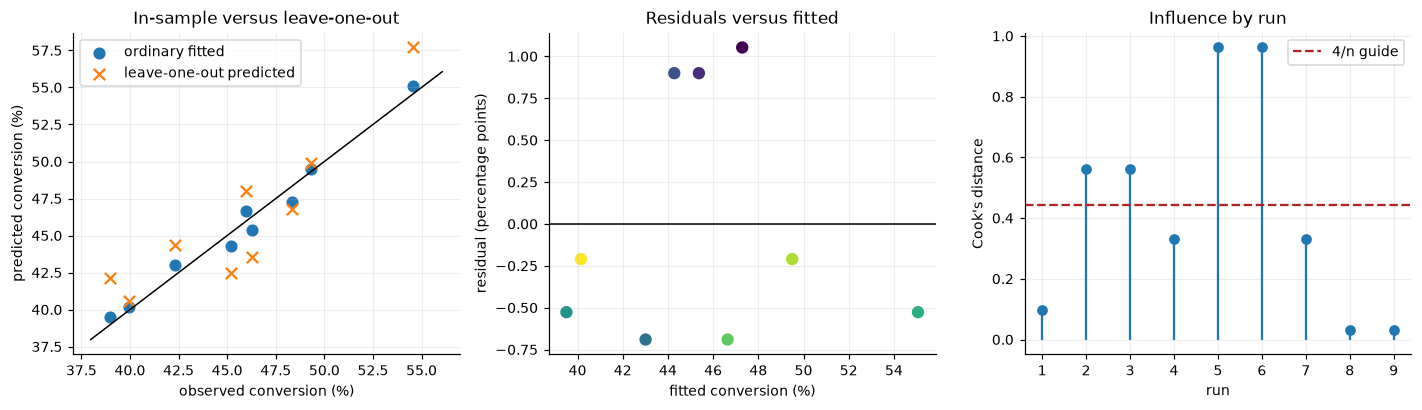

,run,observed_pct,fitted_pct,loo_predicted_pct,leverage,cooks_d
5,6,54.54,55.0667,57.70,0.8333,0.9621
4,5,38.98,39.5067,42.14,0.8333,0.9621
1,2,46.27,45.3700,43.57,0.6667,0.5619
2,3,45.18,44.2800,42.48,0.6667,0.5619
3,4,42.32,43.0100,44.39,0.6667,0.3303
6,7,45.95,46.6400,48.02,0.6667,0.3303
0,1,48.34,47.2867,46.76,0.3333,0.0962
7,8,49.29,49.5000,49.92,0.6667,0.0306
8,9,39.94,40.1500,40.57,0.6667,0.0306


In [9]:
fitted = fit.fittedvalues
loo_predicted = y - press_residuals
cooks_d = influence.cooks_distance[0]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].scatter(y, fitted, label="ordinary fitted", s=48)
axes[0].scatter(y, loo_predicted, marker="x", s=55, label="leave-one-out predicted")
limits = [min(y.min(), loo_predicted.min()) - 1, max(y.max(), fitted.max()) + 1]
axes[0].plot(limits, limits, color="black", lw=1)
axes[0].set(xlabel="observed conversion (%)", ylabel="predicted conversion (%)", title="In-sample versus leave-one-out")
axes[0].legend()

axes[1].scatter(fitted, fit.resid, c=data["run"], cmap="viridis", s=50)
axes[1].axhline(0, color="black", lw=1)
axes[1].set(xlabel="fitted conversion (%)", ylabel="residual (percentage points)", title="Residuals versus fitted")

axes[2].stem(data["run"], cooks_d, basefmt=" ")
axes[2].axhline(4/len(data), color="firebrick", ls="--", label="4/n guide")
axes[2].set(xlabel="run", ylabel="Cook's distance", title="Influence by run")
axes[2].legend()
fig.tight_layout()
plt.show()

pd.DataFrame({
    "run": data["run"], "observed_pct": y, "fitted_pct": fitted,
    "loo_predicted_pct": loo_predicted, "leverage": influence.hat_matrix_diag,
    "cooks_d": cooks_d,
}).sort_values("cooks_d", ascending=False)

## 6. Validate against the paper

The validation table uses printed precision to set tolerances. “Adequate precision” is reproduced using Design-Expert's signal definition for this linear model: range of fitted responses divided by the average prediction standard error, $\sqrt{p\,MSE/n}$.

In [10]:
validation_items = [
    ("R²", 0.9770, fit.rsquared, 0.0001),
    ("Adjusted R²", 0.9388, fit.rsquared_adj, 0.0001),
    ("Model SS", 184.07, model_ss, 0.02),
    ("Residual SS", 4.32, full_sse, 0.01),
    ("Model F", 25.54, fit.fvalue, 0.02),
    ("Model p", 0.0116, fit.f_pvalue, 0.0001),
    ("RMSE (denominator n)", 0.6932, rmse_n, 0.0001),
    ("Residual standard deviation", 1.20, residual_sd, 0.01),
    ("CV (%)", 2.63, cv_pct, 0.01),
    ("PRESS", 46.41, press, 0.02),
    ("Adequate precision", 15.872, adequate_precision, 0.01),
    ("Maximum Table 1 fitted-value error", 0.0, np.max(np.abs(fitted - data["paper_fitted_pct"])), 0.006),
]
validation = pd.DataFrame(validation_items, columns=["target", "published", "reproduced", "tolerance"])
validation["abs_difference"] = (validation["reproduced"] - validation["published"]).abs()
validation["relative_difference"] = validation["abs_difference"] / validation["published"].abs().replace(0, np.nan)
validation["within_tolerance"] = validation["abs_difference"] <= validation["tolerance"]
validation

,target,published,reproduced,tolerance,abs_difference,relative_difference,within_tolerance
0,R²,0.9770,0.9770,0.0001,4.4663e-05,4.5714e-05,True
1,Adjusted R²,0.9388,0.9388,0.0001,1.4232e-05,1.5160e-05,True
2,Model SS,184.0700,184.0702,0.0200,1.5556e-04,8.4509e-07,True
3,Residual SS,4.3200,4.3247,0.0100,4.6667e-03,1.0802e-03,True
4,Model F,25.5400,25.5377,0.0200,2.2877e-03,8.9571e-05,True
5,Model p,0.0116,0.0116,0.0001,3.4202e-05,2.9484e-03,True
6,RMSE (denominator n),0.6932,0.6932,0.0001,5.5695e-06,8.0344e-06,True
7,Residual standard deviation,1.2000,1.2006,0.0100,6.4797e-04,5.3998e-04,True
8,CV (%),2.6300,2.6304,0.0100,3.7213e-04,1.4150e-04,True
9,PRESS,46.4100,46.4112,0.0200,1.2000e-03,2.5856e-05,True


## 7. Go beyond the paper

### 7.1 What a single-observation Taguchi S/N ratio can—and cannot—say

For a larger-is-better response, Taguchi's run-level signal-to-noise statistic is

$$S/N=-10\log_{10}\left(\frac{1}{m}\sum_{r=1}^{m}\frac{1}{y_r^2}\right).$$

Here each setting has only one published response ($m=1$), so $S/N=20\log_{10}(y)$. It is just a monotonic transformation of conversion: it cannot distinguish a high mean from low variability and provides no independent evidence of robustness. We calculate it because it is instructive, while labelling that limitation explicitly.

In [11]:
data["larger_better_sn_db"] = 20 * np.log10(data["conversion_pct"])
factor_labels = {
    "x1": "enzyme amount", "x2": "reaction time",
    "x3": "temperature", "x4": "OA:TEA ratio",
}
level_rows = []
for factor, label in factor_labels.items():
    for level in [-1, 0, 1]:
        subset = data.loc[data[factor] == level]
        level_rows.append((label, level, subset["conversion_pct"].mean(), subset["larger_better_sn_db"].mean()))
level_effects = pd.DataFrame(level_rows, columns=["factor", "coded_level", "mean_conversion_pct", "mean_single_observation_SN_dB"])
display(level_effects.pivot(index="coded_level", columns="factor", values="mean_conversion_pct"))

factor_effect_sizes = level_effects.groupby("factor").agg(
    conversion_delta=("mean_conversion_pct", lambda s: s.max()-s.min()),
    SN_delta_dB=("mean_single_observation_SN_dB", lambda s: s.max()-s.min()),
    best_mean_level=("mean_conversion_pct", lambda s: level_effects.loc[s.idxmax(), "coded_level"]),
).sort_values("conversion_delta", ascending=False)
factor_effect_sizes["conversion_rank"] = factor_effect_sizes["conversion_delta"].rank(ascending=False, method="min").astype(int)
factor_effect_sizes

factor,OA:TEA ratio,enzyme amount,reaction time,temperature
coded_level,,,,
-1,41.7300,43.3700,47.2867,43.5300
0,45.5367,45.8567,47.1700,46.5967
1,49.6700,47.7100,42.4800,46.8100


,conversion_delta,SN_delta_dB,best_mean_level,conversion_rank
factor,,,,
OA:TEA ratio,7.9400,1.5125,1,1
reaction time,4.8067,0.9163,-1,2
enzyme amount,4.3400,0.8032,1,3
temperature,3.2800,0.6294,1,4


The mean-response ranking is OA:TEA ratio > time > enzyme > temperature. The one-observation S/N ranking is nearly the same because the transform is monotonic. This clarifies the source-label problem: the paper's claim that enzyme is the second-largest effect follows its mislabelled coefficient table; the printed run matrix gives time a slightly larger range.

### 7.2 Confirmation conditions, interpolation, and desirability

The paper reports three confirmations generated by a desirability optimization that penalized enzyme amount, reaction time, and temperature while seeking high conversion. Exact desirability ramps, weights, and importance values are not reported, so the optimizer is not uniquely reproducible.

We can reproduce all three predictions from the Table 1 model. We also test whether each coded condition lies in the convex hull of the nine L9 points. This is stricter than merely checking factor bounds.

In [12]:
confirmation = pd.DataFrame([
    (1, 5.50, 14.06, 61.00, 2.00, 47.34, 48.49, 2.37),
    (2, 5.50, 14.00, 60.83, 2.00, 46.27, 48.44, 4.48),
    (3, 5.50, 14.44, 61.00, 2.00, 49.94, 48.42, 3.14),
], columns=["experiment", "enzyme_pct", "time_h", "temperature_C", "oa_to_tea_ratio", "actual_pct", "paper_predicted_pct", "paper_relative_deviation_pct"])
confirmation_coded = np.column_stack([
    (confirmation["enzyme_pct"] - 5) / 2,
    (confirmation["time_h"] - 16) / 8,
    (confirmation["temperature_C"] - 60) / 5,
    confirmation["oa_to_tea_ratio"] - 2,
])
confirmation_matrix = paper_model_matrix(confirmation_coded)
confirmation["reproduced_predicted_pct"] = fit.predict(pd.DataFrame(confirmation_matrix, columns=paper_terms))
confirmation["reproduced_relative_deviation_pct"] = 100 * np.abs(confirmation["actual_pct"] - confirmation["reproduced_predicted_pct"]) / confirmation["reproduced_predicted_pct"]
information_inverse = np.linalg.inv(X.T @ X)
confirmation_leverage = np.einsum("ij,jk,ik->i", confirmation_matrix, information_inverse, confirmation_matrix)
t_critical = stats.t.ppf(0.975, fit.df_resid)
confirmation_se_mean = np.sqrt(fit.mse_resid * confirmation_leverage)
confirmation_se_prediction = np.sqrt(fit.mse_resid * (1 + confirmation_leverage))
confirmation["mean_CI_low_95_pct"] = confirmation["reproduced_predicted_pct"] - t_critical*confirmation_se_mean
confirmation["mean_CI_high_95_pct"] = confirmation["reproduced_predicted_pct"] + t_critical*confirmation_se_mean
confirmation["prediction_low_95_pct"] = confirmation["reproduced_predicted_pct"] - t_critical*confirmation_se_prediction
confirmation["prediction_high_95_pct"] = confirmation["reproduced_predicted_pct"] + t_critical*confirmation_se_prediction

def in_convex_hull(point, design):
    # Find nonnegative weights summing to one whose weighted design equals point.
    constraints = np.vstack([np.ones(len(design)), design.T])
    target = np.r_[1, point]
    result = optimize.linprog(np.zeros(len(design)), A_eq=constraints, b_eq=target, bounds=(0, None), method="highs")
    return result.success

confirmation["inside_L9_convex_hull"] = [in_convex_hull(point, coded) for point in confirmation_coded]
confirmation

,experiment,enzyme_pct,time_h,temperature_C,oa_to_tea_ratio,actual_pct,paper_predicted_pct,paper_relative_deviation_pct,reproduced_predicted_pct,reproduced_relative_deviation_pct,mean_CI_low_95_pct,mean_CI_high_95_pct,prediction_low_95_pct,prediction_high_95_pct,inside_L9_convex_hull
0,1,5.5,14.06,61.00,2.0,47.34,48.49,2.37,48.4888,2.3693,46.3181,50.6596,44.0943,52.8834,True
1,2,5.5,14.00,60.83,2.0,46.27,48.44,4.48,48.4427,4.4850,46.2844,50.6009,44.0543,52.8311,True
2,3,5.5,14.44,61.00,2.0,49.94,48.42,3.14,48.4222,3.1345,46.2201,50.6243,44.0121,52.8323,True


Table 6 defines the ratio as **OA:TEA**, so the numeric level 2 means 2:1. The prose describing the optimum calls the same amounts (17.70 mmol OA and 8.85 mmol TEA) “1:2,” which reverses the ratio direction. The amounts and Table 6 support OA:TEA = 2:1; the notebook treats the prose as a likely notation error.

All three confirmation settings are geometric interpolations within the L9 hull. Their empirical agreement is useful, but three different outcomes at nearby conditions also show experimental variability that the unreplicated L9 itself could not estimate.

### 7.3 Response-only optimization with explicit bounds

For contrast, we maximize only the reproduced conversion equation over the coded cube. This is **not** the paper's multi-criterion optimum: it ignores enzyme cost and preferences for shorter/cooler processing. The comparison makes clear why desirability definitions are part of a reproducible optimization.

In [13]:
def predict_model(points):
    matrix = pd.DataFrame(paper_model_matrix(np.atleast_2d(points)), columns=paper_terms)
    return fit.predict(matrix).to_numpy()

response_opt = optimize.differential_evolution(
    lambda z: -float(predict_model(z)[0]), bounds=[(-1, 1)]*4, seed=SEED, polish=True,
)
opt_coded = response_opt.x
response_only_optimum = pd.Series({
    "x1": opt_coded[0], "x2": opt_coded[1], "x3": opt_coded[2], "x4": opt_coded[3],
    "enzyme_pct": 5 + 2*opt_coded[0],
    "time_h": 16 + 8*opt_coded[1],
    "temperature_C": 60 + 5*opt_coded[2],
    "OA:TEA numeric ratio": 2 + opt_coded[3],
    "predicted_conversion_pct": -response_opt.fun,
    "inside_L9_convex_hull": in_convex_hull(opt_coded, coded),
}, name="response-only optimum")
response_only_optimum.to_frame()

,response-only optimum
x1,1.0
x2,-0.5255
x3,1.0
x4,1.0
enzyme_pct,7.0
time_h,11.7959
temperature_C,65.0
OA:TEA numeric ratio,3.0
predicted_conversion_pct,55.5815
inside_L9_convex_hull,False


The response-only maximum lies outside the convex hull and pushes enzyme, temperature, and OA:TEA ratio to their upper bounds. It should not be treated as established performance. The paper's lower-resource confirmation setting is a different, multi-objective engineering choice.

### 7.4 Equal-budget comparison with random nine-run designs

This teaching simulation compares the L9 with 1,000 random nine-point subsets of the same $3^4=81$ candidate grid. The target is the full categorical main-effect model (linear and quadratic contrast for each factor). $D$ information measures joint coefficient precision; maximum scaled prediction variance measures the worst grid-point uncertainty. Both comparisons use identical run budgets and candidate spaces.

,value
L9 D information (larger better),0.4280
full-rank random designs (%),41.1000
random full-rank median D information,0.2057
L9 maximum scaled prediction variance (smaller better),9.0000
random full-rank median max scaled variance,243.0000


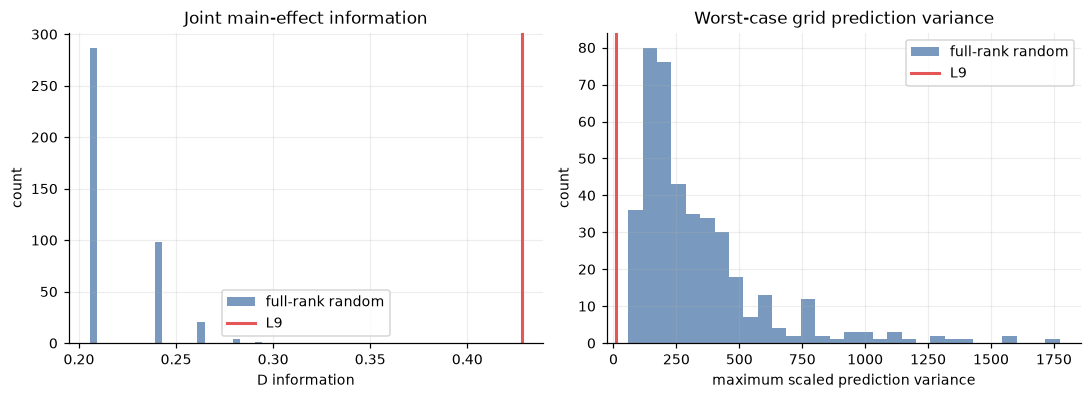

In [14]:
candidate_grid = np.array(np.meshgrid(*[[-1, 0, 1]]*4)).reshape(4, -1).T

def categorical_design_metrics(points):
    matrix = categorical_main_matrix(points)
    if np.linalg.matrix_rank(matrix) < matrix.shape[1]:
        return np.nan, np.inf
    normalized_information = matrix.T @ matrix / len(matrix)
    sign, logdet = np.linalg.slogdet(normalized_information)
    d_information = np.exp(logdet / matrix.shape[1]) if sign > 0 else np.nan
    inverse_information = np.linalg.inv(matrix.T @ matrix)
    evaluation = categorical_main_matrix(candidate_grid)
    scaled_variance = len(matrix) * np.einsum("ij,jk,ik->i", evaluation, inverse_information, evaluation)
    return d_information, scaled_variance.max()

l9_metrics = categorical_design_metrics(coded)
random_metrics = np.array([
    categorical_design_metrics(candidate_grid[rng.choice(len(candidate_grid), 9, replace=False)])
    for _ in range(1000)
])
full_rank = np.isfinite(random_metrics[:, 1])
comparison = pd.Series({
    "L9 D information (larger better)": l9_metrics[0],
    "full-rank random designs (%)": 100*full_rank.mean(),
    "random full-rank median D information": np.nanmedian(random_metrics[:, 0]),
    "L9 maximum scaled prediction variance (smaller better)": l9_metrics[1],
    "random full-rank median max scaled variance": np.median(random_metrics[full_rank, 1]),
}, name="value")
display(comparison.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
axes[0].hist(random_metrics[np.isfinite(random_metrics[:, 0]), 0], bins=24, color="#4c78a8", alpha=0.75, label="full-rank random")
axes[0].axvline(l9_metrics[0], color="#e45756", lw=2, label="L9")
axes[0].set(xlabel="D information", ylabel="count", title="Joint main-effect information")
axes[0].legend()
axes[1].hist(random_metrics[full_rank, 1], bins=30, color="#4c78a8", alpha=0.75, label="full-rank random")
axes[1].axvline(l9_metrics[1], color="#e45756", lw=2, label="L9")
axes[1].set(xlabel="maximum scaled prediction variance", ylabel="count", title="Worst-case grid prediction variance")
axes[1].legend()
fig.tight_layout()
plt.show()

The L9's advantage is structural: it is guaranteed full rank for the four-factor categorical main-effect model and has balanced projections. Many random nine-point subsets are singular; even full-rank random subsets have much worse worst-case prediction variance. This is what the orthogonal array buys. It does **not** buy interaction identification, replication, or robustness evidence.

## 8. Practitioner conclusions

- **What DoE made possible.** Nine strategically chosen flasks covered all levels of four factors and all pairwise level projections. A comparable ad hoc or OFAT sequence would not provide this balance and would confound factor changes with the chosen path.
- **What OFAT would miss.** OFAT cannot diagnose interactions, and this L9 cannot estimate them either—but the L9 makes the aliasing explicit and estimates main-effect contrasts much more efficiently.
- **Which effects are supported.** Under the restricted numeric model, OA:TEA ratio is largest; time, enzyme, and temperature also contribute. The paper's factor-label permutation changes the verbal ranking and must be corrected before interpretation.
- **Which effects are merely fitted.** Time curvature is plausible but has $p=0.0742$ and no pure-error benchmark. Interactions are exactly aliased with combinations of main polynomial contrasts.
- **Where prediction is trustworthy.** The three confirmation settings are within the observed design hull. The response-only cube maximum is outside it and is extrapolative.
- **Design limitations.** No repeated settings, noise-factor array, blocks, or documented randomization are available. Pure error, lack of fit, and process robustness cannot be separated.
- **Response-model limitations.** Three residual degrees of freedom make uncertainty fragile. In-sample $R^2$ is high, while leave-one-out predicted $R^2$ is lower and more realistic.
- **Mistakes to avoid.** Do not equate “Taguchi” with demonstrated robustness, interpret a single-observation S/N transform as variance evidence, add aliased interactions, reverse ratio notation, or reproduce a desirability optimum without its weights and ramps.

## 9. Reproducibility metadata

The checksum covers the exact Table 1 transcription, including printed fitted values. The execution date is fixed here as provenance for this completed reproduction; package versions are captured dynamically from the clean kernel.

In [15]:
metadata = pd.Series({
    "execution_date": "2026-08-01",
    "random_seed": SEED,
    "table1_sha256": DATA_SHA256,
    "notebook": "fardmasoumi2011.ipynb",
    **versions,
}, name="value")
metadata.to_frame()

,value
execution_date,2026-08-01
random_seed,20110603
table1_sha256,88170e526c227266d3e815858b3ed88144c7b303a791b4...
notebook,fardmasoumi2011.ipynb
Python,3.13.2
pydoe,1.3.1.dev11+geca1a2598
numpy,2.3.4
pandas,3.0.0
scipy,1.16.2
statsmodels,0.14.6
